<a href="https://colab.research.google.com/github/khadija2027/Medical-image-classification-using-QCNN/blob/main/Data_encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Installing and importing**

In [ ]:
!pip install medmnist -q
!pip install pennylane -q

import os
import json
import time
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import pennylane as qml
from medmnist import PneumoniaMNIST
from torchvision import transforms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 103.6 MB/s eta 0:00:00


**Configuration**

In [ ]:
DRIVE_PATH   = '/content/drive/MyDrive/Research_intership_khadija_ELMRABET/Deliverables/Codes'
if not os.path.isdir('/content/drive'):          # not in Colab -> local fallback
    DRIVE_PATH = './Encoding data methods/'
CKPT_DIR     = os.path.join(DRIVE_PATH, 'qcnn_checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

N_QUBITS     = 8
N_EPOCHS     = 20
BATCH_SIZE   = 32
LR           = 0.01
TRAIN_SUBSET = None     # set None to use the FULL train set (much slower)
VAL_SUBSET   = None    # set None to use the full val set
SEED         = 42

ENCODINGS = ["basis", "angle", "dense_angle", "amplitude", "hybrid"]

torch.manual_seed(SEED)
np.random.seed(SEED)

**FEATURE PREPARATION  (28x28 image -> encoding-specific feature vector)**


ENCODING: basis
  epoch  1/20 | train 0.555/0.716 | val 0.583/0.712 | best 0.712 | 15.4s
  epoch  2/20 | train 0.527/0.752 | val 0.562/0.725 | best 0.725 | 15.5s
  epoch  3/20 | train 0.521/0.755 | val 0.546/0.727 | best 0.727 | 16.4s
  epoch  4/20 | train 0.517/0.756 | val 0.553/0.735 | best 0.735 | 15.9s
  epoch  5/20 | train 0.518/0.754 | val 0.547/0.729 | best 0.735 | 16.2s
  epoch  6/20 | train 0.517/0.757 | val 0.545/0.729 | best 0.735 | 18.8s
  epoch  7/20 | train 0.516/0.755 | val 0.545/0.729 | best 0.735 | 16.8s
  epoch  8/20 | train 0.515/0.757 | val 0.541/0.737 | best 0.737 | 16.1s
  epoch  9/20 | train 0.516/0.754 | val 0.543/0.729 | best 0.737 | 16.3s
  epoch 10/20 | train 0.515/0.757 | val 0.542/0.737 | best 0.737 | 16.8s
  epoch 11/20 | train 0.515/0.756 | val 0.542/0.744 | best 0.744 | 17.6s
  epoch 12/20 | train 0.515/0.759 | val 0.543/0.729 | best 0.744 | 16.9s
  epoch 13/20 | train 0.516/0.756 | val 0.544/0.735 | best 0.744 | 15.8s
  epoch 14/20 | train 0.515/0.758 

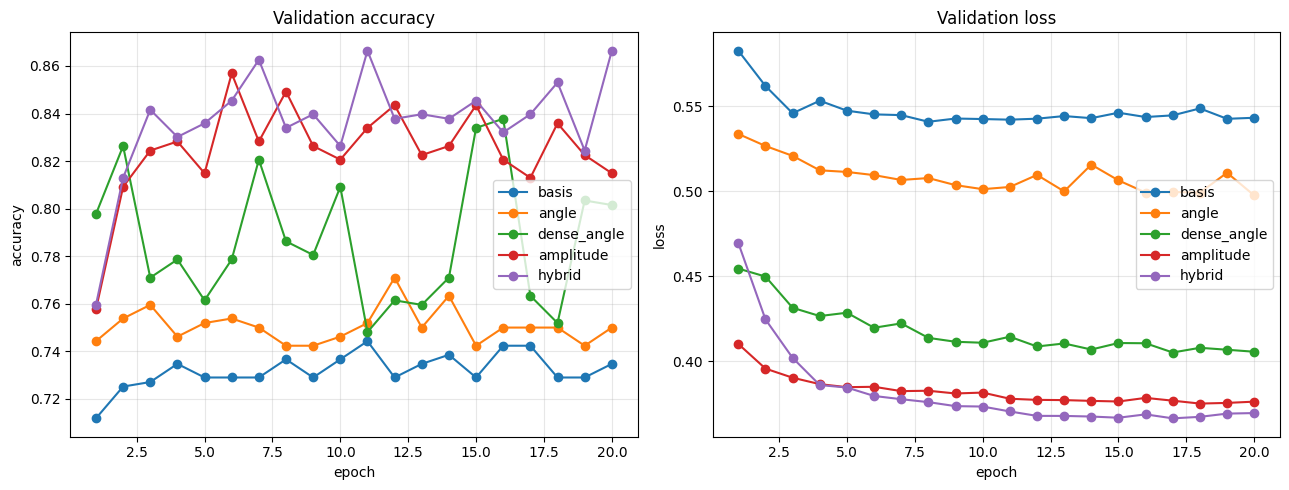

In [ ]:
# We downsample with adaptive average pooling so every encoding gets exactly the number of features it can hold.
def prep_features(img, encoding):
    b = img.size(0)
    if encoding == "amplitude":
        # 2^8 = 256 amplitudes  ->  16x16 downsample. Embedding L2-normalizes.
        x = F.adaptive_avg_pool2d(img, (16, 16)).reshape(b, -1)          # (B,256)
        return x
    if encoding == "dense_angle":
        # 2 features / qubit -> 16 features -> 4x4 downsample, mapped to [0, pi]
        x = F.adaptive_avg_pool2d(img, (4, 4)).reshape(b, -1)            # (B,16)
        return (x + 1.0) / 2.0 * np.pi
    if encoding == "basis":
        # 8 binary features -> 2x4 downsample, thresholded to {0,1}
        x = F.adaptive_avg_pool2d(img, (2, 4)).reshape(b, -1)            # (B,8)
        return (x > 0).float()
    if encoding == "hybrid":
        # State(amplitude) part: 16 features (2^4) -> qubits 0-3 (L2-normalized)
        amp = F.adaptive_avg_pool2d(img, (4, 4)).reshape(b, -1)          # (B,16)
        # Angle part: 4 features -> qubits 4-7, mapped to [0, pi]
        ang = F.adaptive_avg_pool2d(img, (2, 2)).reshape(b, -1)          # (B,4)
        ang = (ang + 1.0) / 2.0 * np.pi
        return torch.cat([amp, ang], dim=1)                             # (B,20)
    # angle: 8 continuous features -> 2x4 downsample, mapped to [0, pi]
    x = F.adaptive_avg_pool2d(img, (2, 4)).reshape(b, -1)                # (B,8)
    return (x + 1.0) / 2.0 * np.pi

# 2. ENCODING CIRCUITS
def encode(inputs, encoding):
    if encoding == "angle":
        qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="Y")

    elif encoding == "dense_angle":
        for i in range(N_QUBITS):
            qml.RY(inputs[..., 2 * i],     wires=i)
            qml.RZ(inputs[..., 2 * i + 1], wires=i)

    elif encoding == "amplitude":
        qml.AmplitudeEmbedding(inputs, wires=range(N_QUBITS),
                               normalize=True, pad_with=0.0)

    elif encoding == "hybrid":
        # Merge state-vector (amplitude) encoding with angle encoding.
        # Qubits 0-3: amplitude encoding of 16 features (dense/exponential).
        qml.AmplitudeEmbedding(inputs[..., :16], wires=range(4),
                               normalize=True, pad_with=0.0)
        # Qubits 4-7: angle encoding of 4 features (direct/magnitude-aware).
        qml.AngleEmbedding(inputs[..., 16:20], wires=range(4, 8), rotation="Y")

    elif encoding == "basis":
        for i in range(N_QUBITS):
            qml.RX(np.pi * inputs[..., i], wires=i)
    else:
        raise ValueError(f"Unknown encoding: {encoding}")


# ----------------------------------------------------------------------------
# 3. QCNN ANSATZ  (convolution + pooling, 8 -> 4 -> 2 -> 1 qubits)
# ----------------------------------------------------------------------------
def conv_block(w, wires):          # w: 6 trainable params
    a, b = wires
    qml.RY(w[0], wires=a); qml.RY(w[1], wires=b)
    qml.CNOT(wires=[a, b])
    qml.RY(w[2], wires=a); qml.RY(w[3], wires=b)
    qml.CNOT(wires=[b, a])
    qml.RY(w[4], wires=a); qml.RY(w[5], wires=b)

def pool_block(w, wires):          # w: 2 params. Keeps the SECOND wire.
    a, b = wires
    qml.CRZ(w[0], wires=[a, b])
    qml.PauliX(wires=a)
    qml.CRX(w[1], wires=[a, b])

def conv_layer(weights, pairs):
    for i, pr in enumerate(pairs):
        conv_block(weights[i], pr)

def pool_layer(weights, pairs):
    for i, pr in enumerate(pairs):
        pool_block(weights[i], pr)

def make_circuit(encoding):
    def circuit(inputs, conv1, pool1, conv2, pool2, conv3, pool3):
        encode(inputs, encoding)
        # Layer 1: 8 qubits -> keep 1,3,5,7
        conv_layer(conv1, [(0, 1), (2, 3), (4, 5), (6, 7)])
        pool_layer(pool1, [(0, 1), (2, 3), (4, 5), (6, 7)])
        # Layer 2: {1,3,5,7} -> keep 3,7
        conv_layer(conv2, [(1, 3), (5, 7)])
        pool_layer(pool2, [(1, 3), (5, 7)])
        # Layer 3: {3,7} -> keep 7
        conv_layer(conv3, [(3, 7)])
        pool_layer(pool3, [(3, 7)])
        return qml.expval(qml.PauliZ(7))
    return circuit

WEIGHT_SHAPES = {
    "conv1": (4, 6), "pool1": (4, 2),
    "conv2": (2, 6), "pool2": (2, 2),
    "conv3": (1, 6), "pool3": (1, 2),
}   # 56 trainable quantum parameters total


class QCNN(nn.Module):
    def __init__(self, encoding):
        super().__init__()
        self.encoding = encoding
        dev = qml.device("default.qubit", wires=N_QUBITS)
        qnode = qml.QNode(make_circuit(encoding), dev,
                          interface="torch", diff_method="backprop")
        self.qlayer = qml.qnn.TorchLayer(qnode, WEIGHT_SHAPES)

    def forward(self, img):
        feats = prep_features(img, self.encoding)
        z = self.qlayer(feats).reshape(-1)          # expval(Z) in [-1, 1]
        p = (1.0 - z) / 2.0                          # prob of class 1
        return p.clamp(1e-6, 1 - 1e-6)


# ----------------------------------------------------------------------------
# 4. DATA
# ----------------------------------------------------------------------------
def get_loaders():
    tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])
    train = PneumoniaMNIST(split="train", download=True, size=28, transform=tf)
    val   = PneumoniaMNIST(split="val",   download=True, size=28, transform=tf)
    test  = PneumoniaMNIST(split="test",  download=True, size=28, transform=tf)

    if TRAIN_SUBSET:
        train = Subset(train, range(min(TRAIN_SUBSET, len(train))))
    if VAL_SUBSET:
        val = Subset(val, range(min(VAL_SUBSET, len(val))))

    tl = DataLoader(train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    vl = DataLoader(val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    sl = DataLoader(test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    return tl, vl, sl


# ----------------------------------------------------------------------------
# 5. CHECKPOINTING
# ----------------------------------------------------------------------------
def ckpt_path(enc):  return os.path.join(CKPT_DIR, f"{enc}.pth")
def best_path(enc):  return os.path.join(CKPT_DIR, f"{enc}_best.pth")

def save_ckpt(enc, model, opt, epoch, best_acc, history):
    torch.save({
        "epoch": epoch, "best_acc": best_acc, "history": history,
        "model": model.state_dict(), "opt": opt.state_dict(),
    }, ckpt_path(enc))


# ----------------------------------------------------------------------------
# 6. TRAIN / EVAL
# ----------------------------------------------------------------------------
def run_epoch(model, loader, criterion, opt=None):
    train = opt is not None
    model.train() if train else model.eval()
    tot_loss, correct, n = 0.0, 0, 0
    for img, y in loader:
        y = y.float().reshape(-1)
        if train:
            opt.zero_grad()
        p = model(img)
        loss = criterion(p, y)
        if train:
            loss.backward()
            opt.step()
        tot_loss += loss.item() * y.size(0)
        correct  += ((p > 0.5).float() == y).sum().item()
        n        += y.size(0)
    return tot_loss / n, correct / n

def train_encoding(enc, train_loader, val_loader):
    print(f"\n{'='*60}\nENCODING: {enc}\n{'='*60}")
    model = QCNN(enc)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.BCELoss()

    start_epoch, best_acc, history = 0, 0.0, []
    if os.path.exists(ckpt_path(enc)):
        ck = torch.load(ckpt_path(enc), map_location="cpu")
        model.load_state_dict(ck["model"])
        opt.load_state_dict(ck["opt"])
        start_epoch = ck["epoch"] + 1
        best_acc    = ck["best_acc"]
        history     = ck["history"]
        print(f"  Resuming from epoch {start_epoch} (best val acc={best_acc:.4f})")

    if start_epoch >= N_EPOCHS:
        print("  Already finished. Skipping.")
        return history

    for epoch in range(start_epoch, N_EPOCHS):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, opt)
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion)
        history.append({"epoch": epoch, "train_loss": tr_loss, "train_acc": tr_acc,
                        "val_loss": vl_loss, "val_acc": vl_acc})
        if vl_acc > best_acc:
            best_acc = vl_acc
            torch.save(model.state_dict(), best_path(enc))
        save_ckpt(enc, model, opt, epoch, best_acc, history)   # <-- resume point
        print(f"  epoch {epoch+1:2d}/{N_EPOCHS} | "
              f"train {tr_loss:.3f}/{tr_acc:.3f} | "
              f"val {vl_loss:.3f}/{vl_acc:.3f} | "
              f"best {best_acc:.3f} | {time.time()-t0:.1f}s")
    return history

@torch.no_grad()
def test_encoding(enc, test_loader):
    model = QCNN(enc)
    if os.path.exists(best_path(enc)):
        model.load_state_dict(torch.load(best_path(enc), map_location="cpu"))
    _, acc = run_epoch(model, test_loader, nn.BCELoss())
    return acc


# ----------------------------------------------------------------------------
# 7. MAIN
# ----------------------------------------------------------------------------
def main():
    train_loader, val_loader, test_loader = get_loaders()
    results = {}
    for enc in ENCODINGS:
        history = train_encoding(enc, train_loader, val_loader)
        test_acc = test_encoding(enc, test_loader)
        best_val = max((h["val_acc"] for h in history), default=0.0)
        results[enc] = {"best_val_acc": best_val, "test_acc": test_acc,
                        "history": history}
        print(f"  --> {enc}: best val {best_val:.4f} | test {test_acc:.4f}")

    with open(os.path.join(CKPT_DIR, "results.json"), "w") as f:
        json.dump(results, f, indent=2)

    print(f"\n{'='*60}\nSUMMARY (best val / test accuracy)\n{'='*60}")
    print(f"{'encoding':<14}{'best_val':>10}{'test':>10}")
    for enc in ENCODINGS:
        r = results[enc]
        print(f"{enc:<14}{r['best_val_acc']:>10.4f}{r['test_acc']:>10.4f}")

    try:
        plot_results(results)
    except Exception as e:
        print(f"(plot skipped: {e})")
    return results

def plot_results(results):
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    for enc in ENCODINGS:
        h = results[enc]["history"]
        if not h:
            continue
        ep = [x["epoch"] + 1 for x in h]
        ax[0].plot(ep, [x["val_acc"] for x in h],  marker="o", label=enc)
        ax[1].plot(ep, [x["val_loss"] for x in h], marker="o", label=enc)
    ax[0].set(title="Validation accuracy", xlabel="epoch", ylabel="accuracy")
    ax[1].set(title="Validation loss",     xlabel="epoch", ylabel="loss")
    for a in ax:
        a.legend(); a.grid(alpha=0.3)
    fig.tight_layout()
    out = os.path.join(CKPT_DIR, "comparison.png")
    fig.savefig(out, dpi=130)
    print(f"Saved plot -> {out}")


if __name__ == "__main__":
    main()